# SO(2)-equivariant module ansatz vs. Hamiltonian Neural Network on planar Kepler dynamics

This notebook is a complete, end-to-end experiment for learning the planar Kepler/two-body vector field

\[
(q,p) \mapsto (\dot q, \dot p), \qquad q,p\in\mathbb R^2,
\]

under the diagonal SO(2) action

\[
(q,p) \mapsto (Rq,Rp), \qquad (\dot q,\dot p)\mapsto (R\dot q,R\dot p).
\]

The main model is the invariant/module-generator ansatz

\[
F_\theta(x)=\sum_{i=1}^M c_{\theta,i}(r_1(x),\ldots,r_R(x))m_i(x),
\]

where the scalar network learns only coefficient functions on invariant coordinates. The code is organized so that the learning procedure is group-agnostic: for another group or representation, replace only the invariant map and the module-generator map.

The baseline is a Hamiltonian Neural Network (HNN) trained from derivative labels, following Greydanus, Dzamba, and Yosinski (NeurIPS 2019). HNNs enforce Hamiltonian structure, while the module ansatz enforces SO(2)-equivariance exactly.

References:

- Greydanus, S., Dzamba, M., & Yosinski, J. (2019). *Hamiltonian Neural Networks*. NeurIPS.
- Zhong, Y. D., Dey, B., & Chakraborty, A. (2020). *Symplectic ODE-Net*. ICLR.
- Finzi, M., Welling, M., & Wilson, A. G. (2021). *A Practical Method for Constructing Equivariant Multilayer Perceptrons for Arbitrary Matrix Groups*. ICML.

In [1]:
# This notebook is intended to be run from the repository's notebooks/ directory.
# It also works when copied elsewhere, provided PyTorch, NumPy, pandas, and matplotlib are available.

from __future__ import annotations

import os
import sys
import math
import time
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Protocol

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Allow imports from ../src if the project is not installed in editable mode.
ROOT = Path.cwd().resolve()
for candidate in (ROOT, ROOT.parent, ROOT.parent.parent):
    src = candidate / "src"
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))

USE_FLOAT64 = bool(int(os.environ.get("USE_FLOAT64", "0")))
DTYPE = torch.float64 if USE_FLOAT64 else torch.float32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(DTYPE)

# Set FAST_DEV_RUN=1 in the environment to execute a quick smoke test.
FAST_DEV_RUN = bool(int(os.environ.get("FAST_DEV_RUN", "0")))

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"device={DEVICE}, dtype={DTYPE}, FAST_DEV_RUN={FAST_DEV_RUN}")

device=cpu, dtype=torch.float32, FAST_DEV_RUN=False


## 1. Group-agnostic learning machinery

The only group-specific ingredients are:

1. an invariant-coordinate map
   \[
   r:X\to\mathbb R^R,\qquad r(gx)=r(x),
   \]
2. a module-generator map
   \[
   m:X\to\mathbb R^{M\times d_Y},
   \qquad m_i(gx)=\rho_Y(g)m_i(x).
   \]

The model below then satisfies exact equivariance by construction:

\[
F_\theta(gx)
=\sum_i c_i(r(gx))m_i(gx)
=\rho_Y(g)\sum_i c_i(r(x))m_i(x).
\]

In [2]:
TensorMap = Callable[[torch.Tensor], torch.Tensor]


class VectorFieldProtocol(Protocol):
    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        ...


class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        hidden_dim: int = 128,
        depth: int = 3,
        activation: type[nn.Module] = nn.Tanh,
    ) -> None:
        super().__init__()
        if depth < 1:
            raise ValueError("depth must be at least 1")
        layers: list[nn.Module] = []
        last = in_dim
        for _ in range(depth):
            layers += [nn.Linear(last, hidden_dim), activation()]
            last = hidden_dim
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Standardizer(nn.Module):
    """Fixed affine standardizer: z = (x - mean) / std."""

    def __init__(self, mean: torch.Tensor, std: torch.Tensor, eps: float = 1e-12) -> None:
        super().__init__()
        self.register_buffer("mean", mean.detach().clone())
        self.register_buffer("std", std.detach().clone().clamp_min(eps))

    @classmethod
    def fit(cls, x: torch.Tensor, eps: float = 1e-12) -> "Standardizer":
        return cls(x.mean(dim=0), x.std(dim=0).clamp_min(eps), eps=eps)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


@dataclass(frozen=True)
class ModuleAnsatzSpec:
    """Group-agnostic specification of an equivariant module ansatz.

    invariant_map(x) must return shape (batch, invariant_dim).
    module_map(x) must return shape (batch, generator_count, output_dim).

    The learner is agnostic to how these functions were obtained. They may be
    handwritten, as in this SO(2) demo, or produced by an external polynomial
    invariant/module-generator computation.
    """

    invariant_map: TensorMap
    module_map: TensorMap
    invariant_dim: int
    generator_count: int
    output_dim: int


class EquivariantModuleAnsatz(nn.Module):
    """F_theta(x) = sum_i coeff_i(r(x)) m_i(x)."""

    def __init__(
        self,
        spec: ModuleAnsatzSpec,
        coefficient_net: nn.Module | None = None,
        invariant_normalizer: nn.Module | None = None,
        hidden_dim: int = 128,
        depth: int = 3,
    ) -> None:
        super().__init__()
        self.spec = spec
        self.invariant_normalizer = invariant_normalizer or nn.Identity()
        self.coefficient_net = coefficient_net or MLP(
            spec.invariant_dim,
            spec.generator_count,
            hidden_dim=hidden_dim,
            depth=depth,
        )

    def coefficients(self, x: torch.Tensor) -> torch.Tensor:
        invariants = self.spec.invariant_map(x)
        invariants = self.invariant_normalizer(invariants)
        return self.coefficient_net(invariants)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        coeffs = self.coefficients(x)                     # (B, M)
        generators = self.spec.module_map(x)               # (B, M, d_Y)
        return torch.einsum("bm,bmd->bd", coeffs, generators)

    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        return self.forward(x)


class PlainVectorFieldMLP(nn.Module):
    """Optional non-equivariant baseline."""

    def __init__(self, input_dim: int, output_dim: int, normalizer: nn.Module | None = None) -> None:
        super().__init__()
        self.normalizer = normalizer or nn.Identity()
        self.net = MLP(input_dim, output_dim, hidden_dim=128, depth=3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(self.normalizer(x))

    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        return self.forward(x)

## 2. HNN baseline

The HNN learns a scalar Hamiltonian \(H_\theta(q,p)\), then predicts

\[
\dot x = J_{\mathrm{can}}\nabla_x H_\theta(x),
\qquad
x=(q_x,q_y,p_x,p_y),
\]

where

\[
J_{\mathrm{can}}=\begin{pmatrix}0&I\\-I&0\end{pmatrix}.
\]

In [3]:
class HamiltonianNeuralNetwork(nn.Module):
    def __init__(self, input_dim: int = 4, hidden_dim: int = 128, depth: int = 3,
                 normalizer: nn.Module | None = None) -> None:
        super().__init__()
        self.normalizer = normalizer or nn.Identity()
        self.hamiltonian = MLP(input_dim, 1, hidden_dim=hidden_dim, depth=depth)
        J = torch.zeros(input_dim, input_dim, dtype=DTYPE)
        n = input_dim // 2
        J[:n, n:] = torch.eye(n, dtype=DTYPE)
        J[n:, :n] = -torch.eye(n, dtype=DTYPE)
        self.register_buffer("J", J)

    def H(self, x: torch.Tensor) -> torch.Tensor:
        return self.hamiltonian(self.normalizer(x)).squeeze(-1)

    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        # HNN training requires derivatives of dH/dx with respect to parameters,
        # hence create_graph=True during optimization.
        x_req = x.detach().clone().requires_grad_(True)
        H_sum = self.H(x_req).sum()
        grad_H = torch.autograd.grad(H_sum, x_req, create_graph=create_graph)[0]
        return grad_H @ self.J.T

## 3. Kepler data and SO(2) structure

The reduced two-body dynamics are

\[
\dot q=p,
\qquad
\dot p=-\mu\frac{q}{\|q\|^3}.
\]

For two planar vectors \(q,p\), the SO(2)-invariant coordinates are

\[
r_1=\|q\|^2,\quad r_2=\|p\|^2,\quad r_3=q^\top p,\quad r_4=q^\top Jp.
\]

A module generating set for one vector output is

\[
q,\;Jq,\;p,\;Jp.
\]

Since the vector field has two vector outputs, \(\dot q\) and \(\dot p\), we use eight generators:

\[
(q,0),(Jq,0),(p,0),(Jp,0),(0,q),(0,Jq),(0,p),(0,Jp).
\]

In [4]:
def J2_apply(v: torch.Tensor) -> torch.Tensor:
    """Apply J = [[0, -1], [1, 0]] to a batch of 2-vectors."""
    return torch.stack((-v[..., 1], v[..., 0]), dim=-1)


def so2_rotation(theta: torch.Tensor) -> torch.Tensor:
    """Return batched 2x2 rotation matrices."""
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.stack(
        (torch.stack((c, -s), dim=-1), torch.stack((s, c), dim=-1)),
        dim=-2,
    )


def rotate_planar_pair(x: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    """Apply the diagonal SO(2) action to x=(q,p)."""
    R = so2_rotation(theta).to(device=x.device, dtype=x.dtype)
    q, p = x[..., :2], x[..., 2:]
    qR = torch.einsum("...ij,...j->...i", R, q)
    pR = torch.einsum("...ij,...j->...i", R, p)
    return torch.cat((qR, pR), dim=-1)


def so2_qp_invariants(x: torch.Tensor) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    r1 = (q * q).sum(dim=-1)
    r2 = (p * p).sum(dim=-1)
    r3 = (q * p).sum(dim=-1)
    r4 = (q * J2_apply(p)).sum(dim=-1)
    return torch.stack((r1, r2, r3, r4), dim=-1)


def so2_qp_module_generators(x: torch.Tensor) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    z = torch.zeros_like(q)
    Jq, Jp = J2_apply(q), J2_apply(p)
    gens = [
        torch.cat((q, z), dim=-1),
        torch.cat((Jq, z), dim=-1),
        torch.cat((p, z), dim=-1),
        torch.cat((Jp, z), dim=-1),
        torch.cat((z, q), dim=-1),
        torch.cat((z, Jq), dim=-1),
        torch.cat((z, p), dim=-1),
        torch.cat((z, Jp), dim=-1),
    ]
    return torch.stack(gens, dim=-2)


def kepler_vector_field(x: torch.Tensor, mu: float = 1.0, eps: float = 1e-9) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    r2 = (q * q).sum(dim=-1, keepdim=True).clamp_min(eps)
    qdot = p
    pdot = -mu * q / r2.pow(1.5)
    return torch.cat((qdot, pdot), dim=-1)


def kepler_energy(x: torch.Tensor, mu: float = 1.0, eps: float = 1e-9) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    r = torch.linalg.norm(q, dim=-1).clamp_min(eps)
    return 0.5 * (p * p).sum(dim=-1) - mu / r


def angular_momentum(x: torch.Tensor) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    return (q * J2_apply(p)).sum(dim=-1)

In [5]:
def sample_kepler_states(
    n: int,
    *,
    theta_range: tuple[float, float],
    r_range: tuple[float, float] = (0.7, 1.5),
    mu: float = 1.0,
    radial_momentum_scale: float = 0.35,
    tangential_speed_range: tuple[float, float] = (0.7, 1.3),
    device: torch.device = DEVICE,
    dtype: torch.dtype = DTYPE,
) -> torch.Tensor:
    """Sample off-circular Kepler states with angle restricted by theta_range."""
    theta = torch.empty(n, device=device, dtype=dtype).uniform_(*theta_range)
    radius = torch.empty(n, device=device, dtype=dtype).uniform_(*r_range)
    e_r = torch.stack((torch.cos(theta), torch.sin(theta)), dim=-1)
    e_t = J2_apply(e_r)
    q = radius[:, None] * e_r

    circ_speed = torch.sqrt(torch.tensor(mu, device=device, dtype=dtype) / radius)
    radial_speed = torch.empty(n, device=device, dtype=dtype).uniform_(
        -radial_momentum_scale, radial_momentum_scale
    )
    tangential_factor = torch.empty(n, device=device, dtype=dtype).uniform_(*tangential_speed_range)
    p = radial_speed[:, None] * e_r + (tangential_factor * circ_speed)[:, None] * e_t
    return torch.cat((q, p), dim=-1)


def make_dataset(n: int, theta_range: tuple[float, float]) -> tuple[torch.Tensor, torch.Tensor]:
    x = sample_kepler_states(n, theta_range=theta_range)
    y = kepler_vector_field(x)
    return x, y


if FAST_DEV_RUN:
    N_TRAIN, N_VAL, N_TEST = 128, 64, 128
    EPOCHS_MODULE, EPOCHS_HNN = 2, 2
else:
    N_TRAIN, N_VAL, N_TEST = 2048, 512, 2048
    EPOCHS_MODULE, EPOCHS_HNN = 250, 250

TRAIN_THETA_RANGE = (-math.pi / 4, math.pi / 4)
TEST_THETA_RANGE = (-math.pi, math.pi)
BATCH_SIZE = 256

x_train, y_train = make_dataset(N_TRAIN, TRAIN_THETA_RANGE)
x_val, y_val = make_dataset(N_VAL, TRAIN_THETA_RANGE)
x_test, y_test = make_dataset(N_TEST, TEST_THETA_RANGE)

print(x_train.shape, y_train.shape, x_test.shape)
print("train angle sector:", TRAIN_THETA_RANGE, "test angle sector:", TEST_THETA_RANGE)

torch.Size([2048, 4]) torch.Size([2048, 4]) torch.Size([2048, 4])
train angle sector: (-0.7853981633974483, 0.7853981633974483) test angle sector: (-3.141592653589793, 3.141592653589793)


## 4. Training and evaluation utilities

In [6]:
def make_loader(x: torch.Tensor, y: torch.Tensor, batch_size: int, shuffle: bool = True) -> DataLoader:
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def model_vector_field(model: nn.Module, x: torch.Tensor, *, train: bool) -> torch.Tensor:
    create_graph = train and isinstance(model, HamiltonianNeuralNetwork)
    return model.vector_field(x, create_graph=create_graph)  # type: ignore[attr-defined]


def train_vector_field_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_data: tuple[torch.Tensor, torch.Tensor],
    *,
    epochs: int,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    print_every: int = 100,
) -> pd.DataFrame:
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    x_val, y_val = val_data
    history: list[dict[str, float]] = []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model_vector_field(model, xb, train=True)
            loss = torch.mean((pred - yb) ** 2)
            loss.backward()
            opt.step()
            total_loss += float(loss.detach()) * xb.shape[0]
            total_count += xb.shape[0]

        train_mse = total_loss / total_count
        val_mse = evaluate_derivative_mse(model, x_val, y_val, batch_size=1024)
        row = {"epoch": epoch, "train_mse": train_mse, "val_mse": val_mse}
        history.append(row)
        if epoch == 1 or epoch == epochs or epoch % print_every == 0:
            print(f"epoch {epoch:4d} | train {train_mse:.3e} | val {val_mse:.3e}")

    elapsed = time.time() - t0
    print(f"finished in {elapsed:.1f}s")
    return pd.DataFrame(history)


def evaluate_derivative_mse(
    model: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    *,
    batch_size: int = 1024,
) -> float:
    model.eval()
    losses = []
    counts = []
    loader = make_loader(x, y, batch_size=batch_size, shuffle=False)
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model_vector_field(model, xb, train=False)
        loss = torch.mean((pred - yb) ** 2)
        losses.append(float(loss.detach()) * xb.shape[0])
        counts.append(xb.shape[0])
    return sum(losses) / sum(counts)


def equivariance_error_so2(
    model: nn.Module,
    x: torch.Tensor,
    *,
    n_group_samples: int = 16,
    eps: float = 1e-12,
) -> float:
    """Mean relative error ||F(Rx)-R F(x)|| / ||F(x)||."""
    model.eval()
    x = x.to(DEVICE)
    errors = []
    for _ in range(n_group_samples):
        theta = torch.empty(x.shape[0], device=DEVICE, dtype=DTYPE).uniform_(-math.pi, math.pi)
        x_rot = rotate_planar_pair(x, theta)
        fx = model_vector_field(model, x, train=False)
        f_xrot = model_vector_field(model, x_rot, train=False)
        rot_fx = rotate_planar_pair(fx, theta)
        rel = torch.linalg.norm(f_xrot - rot_fx, dim=-1) / (torch.linalg.norm(fx, dim=-1) + eps)
        errors.append(float(rel.mean().detach()))
    return float(np.mean(errors))


def summarize_models(models: dict[str, nn.Module]) -> pd.DataFrame:
    rows = []
    small_n = 64 if FAST_DEV_RUN else 512
    group_samples = 2 if FAST_DEV_RUN else 8
    small_x = x_test[: min(small_n, x_test.shape[0])]
    for name, model in models.items():
        rows.append({
            "model": name,
            "train-sector derivative MSE": evaluate_derivative_mse(model, x_val, y_val),
            "all-angle derivative MSE": evaluate_derivative_mse(model, x_test, y_test),
            "SO(2) equivariance error": equivariance_error_so2(model, small_x, n_group_samples=group_samples),
            "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        })
    return pd.DataFrame(rows).sort_values("all-angle derivative MSE")

## 5. Build and train the models

The invariant/module model is instantiated through the group-agnostic `ModuleAnsatzSpec`. For a different group, this is the only specification that should change.

In [7]:
# Fit normalizers using only training data.
invariant_normalizer = Standardizer.fit(so2_qp_invariants(x_train)).to(DEVICE)
input_normalizer = Standardizer.fit(x_train).to(DEVICE)

so2_spec = ModuleAnsatzSpec(
    invariant_map=so2_qp_invariants,
    module_map=so2_qp_module_generators,
    invariant_dim=4,
    generator_count=8,
    output_dim=4,
)

module_model = EquivariantModuleAnsatz(
    so2_spec,
    invariant_normalizer=invariant_normalizer,
    hidden_dim=64,
    depth=3,
).to(DEVICE)

hnn_model = HamiltonianNeuralNetwork(
    input_dim=4,
    hidden_dim=64,
    depth=3,
    normalizer=input_normalizer,
).to(DEVICE)

print("module ansatz parameters:", sum(p.numel() for p in module_model.parameters() if p.requires_grad))
print("HNN parameters:", sum(p.numel() for p in hnn_model.parameters() if p.requires_grad))

# The module ansatz is exactly equivariant even before training.
print("untrained module equivariance error:", equivariance_error_so2(module_model, x_test[:512], n_group_samples=4))

module ansatz parameters: 9160
HNN parameters: 8705
untrained module equivariance error: 2.9679841162533194e-07


In [8]:
train_loader = make_loader(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)

print("Training SO(2) module ansatz")
hist_module = train_vector_field_model(
    module_model,
    train_loader,
    (x_val, y_val),
    epochs=EPOCHS_MODULE,
    lr=2e-3,
    print_every=max(1, EPOCHS_MODULE // 7),
)

print("\nTraining HNN baseline")
hist_hnn = train_vector_field_model(
    hnn_model,
    train_loader,
    (x_val, y_val),
    epochs=EPOCHS_HNN,
    lr=2e-3,
    print_every=max(1, EPOCHS_HNN // 7),
)

Training SO(2) module ansatz
epoch    1 | train 2.562e-01 | val 3.325e-02
epoch   35 | train 6.255e-04 | val 6.317e-04
epoch   70 | train 2.106e-04 | val 2.176e-04
epoch  105 | train 9.484e-05 | val 9.895e-05
epoch  140 | train 1.441e-04 | val 7.411e-05
epoch  175 | train 1.207e-04 | val 4.447e-05
epoch  210 | train 7.903e-05 | val 7.018e-05
epoch  245 | train 3.838e-05 | val 4.481e-05
epoch  250 | train 2.794e-05 | val 3.255e-05
finished in 10.5s

Training HNN baseline
epoch    1 | train 2.496e-01 | val 1.672e-01
epoch   35 | train 8.526e-04 | val 9.266e-04
epoch   70 | train 2.740e-04 | val 3.015e-04
epoch  105 | train 1.317e-04 | val 1.709e-04
epoch  140 | train 7.279e-05 | val 1.050e-04
epoch  175 | train 6.739e-05 | val 7.548e-05
epoch  210 | train 3.981e-05 | val 6.235e-05
epoch  245 | train 6.155e-05 | val 8.723e-05
epoch  250 | train 8.030e-05 | val 1.522e-04
finished in 10.5s


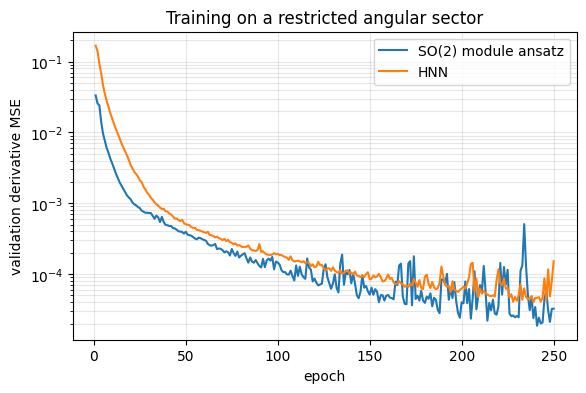

In [9]:
plt.figure(figsize=(6.5, 4))
plt.semilogy(hist_module["epoch"], hist_module["val_mse"], label="SO(2) module ansatz")
plt.semilogy(hist_hnn["epoch"], hist_hnn["val_mse"], label="HNN")
plt.xlabel("epoch")
plt.ylabel("validation derivative MSE")
plt.title("Training on a restricted angular sector")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [10]:
results = summarize_models({
    "SO(2) module ansatz": module_model,
    "HNN": hnn_model,
})
results

,model,train-sector derivative MSE,all-angle derivative MSE,SO(2) equivariance error,parameters
0,SO(2) module ansatz,0.000033,0.000032,1.870863e-07,9160
1,HNN,0.000152,0.261087,1.265920e+00,8705


## 6. Rollout evaluation

Derivative MSE is local. For dynamics learning, compare long rollouts under the learned vector fields. We integrate all models with the same RK4 scheme.

In [11]:
def rk4_step_vector_field(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, dt: float) -> torch.Tensor:
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout_true(x0: torch.Tensor, *, dt: float, steps: int) -> torch.Tensor:
    xs = [x0.detach().clone()]
    x = x0.detach().clone()
    for _ in range(steps):
        x = rk4_step_vector_field(lambda z: kepler_vector_field(z), x, dt).detach()
        xs.append(x)
    return torch.stack(xs, dim=0)


def rollout_model(model: nn.Module, x0: torch.Tensor, *, dt: float, steps: int) -> torch.Tensor:
    model.eval()
    xs = [x0.detach().clone()]
    x = x0.detach().clone()
    for _ in range(steps):
        x = rk4_step_vector_field(lambda z: model_vector_field(model, z, train=False), x, dt).detach()
        xs.append(x)
    return torch.stack(xs, dim=0)


def rollout_metrics(model: nn.Module, x0: torch.Tensor, *, dt: float, steps: int) -> dict[str, float | np.ndarray]:
    true_traj = rollout_true(x0, dt=dt, steps=steps)
    pred_traj = rollout_model(model, x0, dt=dt, steps=steps)
    mse_t = ((pred_traj - true_traj) ** 2).mean(dim=(1, 2)).detach().cpu().numpy()
    H = kepler_energy(pred_traj).detach().cpu().numpy()
    L = angular_momentum(pred_traj).detach().cpu().numpy()
    H0 = H[0]
    L0 = L[0]
    return {
        "trajectory_mse_t": mse_t,
        "mean_trajectory_mse": float(mse_t.mean()),
        "final_trajectory_mse": float(mse_t[-1]),
        "mean_abs_energy_drift": float(np.mean(np.abs(H - H0[None, :]))),
        "mean_abs_angular_momentum_drift": float(np.mean(np.abs(L - L0[None, :]))),
        "pred_traj": pred_traj.detach().cpu().numpy(),
        "true_traj": true_traj.detach().cpu().numpy(),
    }

In [12]:
if FAST_DEV_RUN:
    ROLLOUT_STEPS = 10
    N_ROLLOUTS = 2
else:
    ROLLOUT_STEPS = 150
    N_ROLLOUTS = 8
DT = 0.025

x0 = sample_kepler_states(N_ROLLOUTS, theta_range=TEST_THETA_RANGE).to(DEVICE)
roll_module = rollout_metrics(module_model, x0, dt=DT, steps=ROLLOUT_STEPS)
roll_hnn = rollout_metrics(hnn_model, x0, dt=DT, steps=ROLLOUT_STEPS)

rollout_table = pd.DataFrame([
    {
        "model": "SO(2) module ansatz",
        "mean rollout MSE": roll_module["mean_trajectory_mse"],
        "final rollout MSE": roll_module["final_trajectory_mse"],
        "mean |energy drift|": roll_module["mean_abs_energy_drift"],
        "mean |angular momentum drift|": roll_module["mean_abs_angular_momentum_drift"],
    },
    {
        "model": "HNN",
        "mean rollout MSE": roll_hnn["mean_trajectory_mse"],
        "final rollout MSE": roll_hnn["final_trajectory_mse"],
        "mean |energy drift|": roll_hnn["mean_abs_energy_drift"],
        "mean |angular momentum drift|": roll_hnn["mean_abs_angular_momentum_drift"],
    },
])
rollout_table

,model,mean rollout MSE,final rollout MSE,mean |energy drift|,mean |angular momentum drift|
0,SO(2) module ansatz,0.164562,0.676124,0.130525,0.038618
1,HNN,1.454072,4.221216,2.628213,1.338627


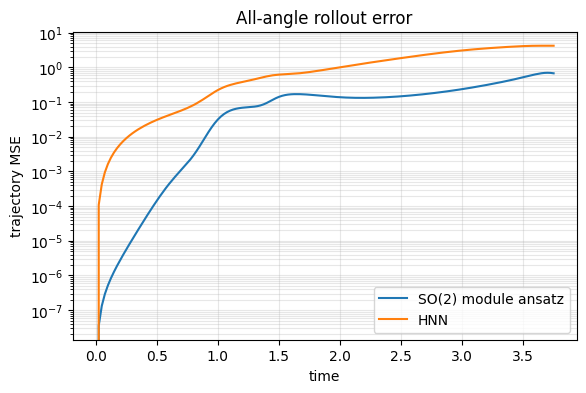

In [13]:
t = np.arange(ROLLOUT_STEPS + 1) * DT
plt.figure(figsize=(6.5, 4))
plt.semilogy(t, roll_module["trajectory_mse_t"], label="SO(2) module ansatz")
plt.semilogy(t, roll_hnn["trajectory_mse_t"], label="HNN")
plt.xlabel("time")
plt.ylabel("trajectory MSE")
plt.title("All-angle rollout error")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

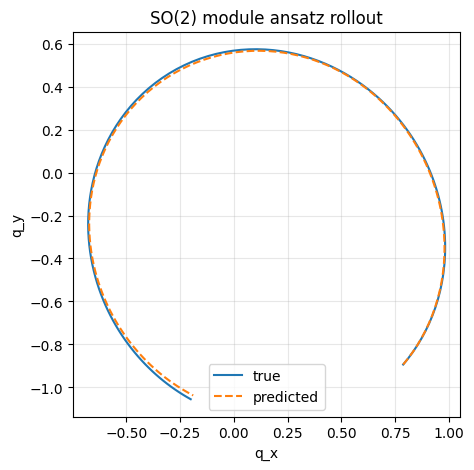

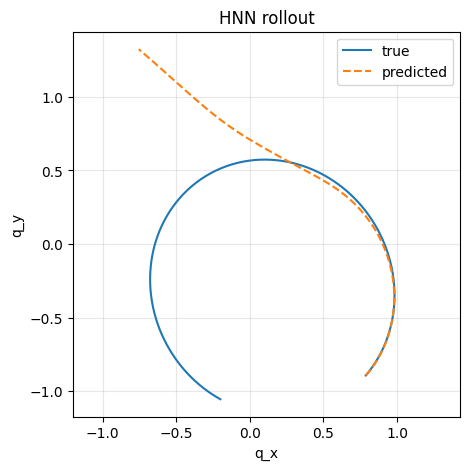

In [14]:
def plot_orbit_comparison(roll: dict[str, float | np.ndarray], title: str, index: int = 0) -> None:
    true_traj = roll["true_traj"][:, index, :]
    pred_traj = roll["pred_traj"][:, index, :]
    plt.figure(figsize=(5, 5))
    plt.plot(true_traj[:, 0], true_traj[:, 1], label="true")
    plt.plot(pred_traj[:, 0], pred_traj[:, 1], "--", label="predicted")
    plt.xlabel("q_x")
    plt.ylabel("q_y")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_orbit_comparison(roll_module, "SO(2) module ansatz rollout")
plot_orbit_comparison(roll_hnn, "HNN rollout")

## 7. Inspect the learned coefficient functions

For the true vector field

\[
\dot q=p,
\qquad
\dot p=-\mu\frac{q}{\|q\|^3},
\]

only two module coefficients are nonzero:

\[
c_3(r)=1,
\qquad
c_5(r)=-\mu r_1^{-3/2}.
\]

This diagnostic is not needed for prediction, but it helps verify that the ansatz learns the intended sparse structure.

In [15]:
@torch.no_grad()
def inspect_coefficients(model: EquivariantModuleAnsatz, x: torch.Tensor, n: int = 8) -> pd.DataFrame:
    model.eval()
    x = x[:n].to(DEVICE)
    coeff = model.coefficients(x).detach().cpu().numpy()
    inv = so2_qp_invariants(x).detach().cpu().numpy()
    names = ["dq<-q", "dq<-Jq", "dq<-p", "dq<-Jp", "dp<-q", "dp<-Jq", "dp<-p", "dp<-Jp"]
    df = pd.DataFrame(coeff, columns=names)
    df.insert(0, "r1=||q||^2", inv[:, 0])
    df["true dq<-p"] = 1.0
    df["true dp<-q"] = -1.0 / np.power(inv[:, 0], 1.5)
    return df

inspect_coefficients(module_model, x_test, n=10)

,r1=||q||^2,dq<-q,dq<-Jq,dq<-p,dq<-Jp,dp<-q,dp<-Jq,dp<-p,dp<-Jp,true dq<-p,true dp<-q
0,1.946893,-0.011224,0.627593,-0.176627,-0.165880,-0.573651,0.195476,-0.320425,-0.418362,1.0,-0.368118
1,2.053199,0.049946,0.526804,-0.189026,-0.122406,-0.439882,0.130345,-0.242760,-0.265873,1.0,-0.339902
2,1.022528,0.020147,0.531469,0.273905,-0.119601,-0.637620,-0.012115,-0.082190,0.455402,1.0,-0.967135
3,0.765372,-0.085190,0.583459,0.517073,-0.176847,-0.840412,0.065867,-0.174341,0.543538,1.0,-1.493452
4,0.996772,-0.218697,0.720935,0.396107,-0.258697,-0.938499,0.258508,-0.227858,0.037723,1.0,-1.004862
5,1.654840,-0.363920,0.740158,-0.013730,-0.204766,-0.698490,0.038703,-0.116811,-0.256694,1.0,-0.469749
6,1.167657,-0.214820,0.685934,0.073974,-0.188384,-0.774117,0.054441,-0.068576,0.039977,1.0,-0.792551
7,1.359658,-0.220633,0.788184,0.166330,-0.270206,-0.899883,0.270978,-0.273131,-0.292855,1.0,-0.630748
8,2.195443,-0.024396,0.702335,-0.015635,-0.249725,-0.650350,0.407694,-0.484747,-0.621828,1.0,-0.307409
9,1.635711,-0.287001,0.638738,-0.094342,-0.158603,-0.590450,0.007723,-0.051172,-0.153756,1.0,-0.478014


## 8. Optional extension: orientation-sensitive SO(2) dynamics

The Kepler field is actually O(2)-equivariant, so it does not require the full orientation-sensitive SO(2) invariant \(q^\top Jp\). To stress-test SO(2) rather than O(2), replace the target by

\[
\dot q=p,
\qquad
\dot p=-\mu\frac{q}{\|q\|^3}+\beta(\|q\|^2)Jp.
\]

This magnetic/gyroscopic term is SO(2)-equivariant but orientation-sensitive. The same module ansatz applies unchanged; only the data-generating vector field changes. HNNs are not designed for this noncanonical forcing unless the physics is incorporated into the Hamiltonian or symplectic structure.

In [16]:
def magnetic_kepler_vector_field(x: torch.Tensor, mu: float = 1.0, beta0: float = 0.25) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    base = kepler_vector_field(x, mu=mu)
    beta = beta0 / (1.0 + (q * q).sum(dim=-1, keepdim=True))
    extra = torch.cat((torch.zeros_like(q), beta * J2_apply(p)), dim=-1)
    return base + extra

# To run the orientation-sensitive experiment, regenerate y_train/y_val/y_test using
# magnetic_kepler_vector_field and rerun the same training/evaluation cells.

## 9. Notes for connecting to generated invariant/module bases

The learning code above needs only the following contract:

```python
spec = ModuleAnsatzSpec(
    invariant_map=my_invariant_evaluator,       # x -> (batch, R)
    module_map=my_module_generator_evaluator,   # x -> (batch, M, output_dim)
    invariant_dim=R,
    generator_count=M,
    output_dim=output_dim,
)
model = EquivariantModuleAnsatz(spec)
```

Thus, for an arbitrary group supported by the polynomial-basis code, the representation-theoretic computation should expose numerical evaluators for a chosen invariant generating set and module generating set. The optimizer, loss, batching, equivariance test, and rollout code do not depend on SO(2).

For dynamics with known Hamiltonian structure, a parallel equivariant-Hamiltonian variant is also possible:

\[
H_\theta(x)=h_\theta(r_1(x),\ldots,r_R(x)),
\qquad
\dot x=J_{\mathrm{can}}\nabla_xH_\theta(x),
\]

which enforces both SO(2)-invariance of the Hamiltonian and canonical Hamiltonian structure.